In [1]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

#pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)

In [2]:
# Make output folder
output_dir = os.path.join('..','plots','behavioural_pilot')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')

In [4]:
unique_subject_ids = [999]
unique_sessions = [23]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)

In [5]:
print(recent_results)

['../../phd_1_task/experiment_output/behavioural_files/experiment_output_sub-999_session-23_computer_and_keyboard_2024-06-12_18-02-24.csv']


In [6]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
print(combined_results_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        0        1.718208e+09     down                Even   
1        1        1.718208e+09     down                Even   
2        2        1.718208e+09     down                Even   
3        3        1.718208e+09       up                Even   
4        4        1.718208e+09       up                Even   
5        5        1.718208e+09       up                Even   
6        6        1.718208e+09       up                Even   
7        7        1.718208e+09       up                Even   
8        8        1.718208e+09     down                True   
9        9        1.718208e+09     down               False   
10      10        1.718208e+09     down               False   
11      11        1.718208e+09       up               False   
12      12        1.718208e+09       up                True   
13      13        1.718208e+09       up               False   
14      14        1.718208e+09     down               F

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [7]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional column for congruency

In [8]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

     stimuli_type  probability_condition   congruency
0               3                     50    undefined
1               1                     50    undefined
2               1                     50    undefined
3               3                     50    undefined
4               3                     50    undefined
5               1                     50    undefined
6               3                     50    undefined
7               1                     50    undefined
8               1                     20    congruent
9               3                     80    congruent
10              3                     80    congruent
11              1                     20    congruent
12              3                     80    congruent
13              1                     20    congruent
14              3                     80    congruent
15              1                     20    congruent
16              3                     80    congruent
17              3           

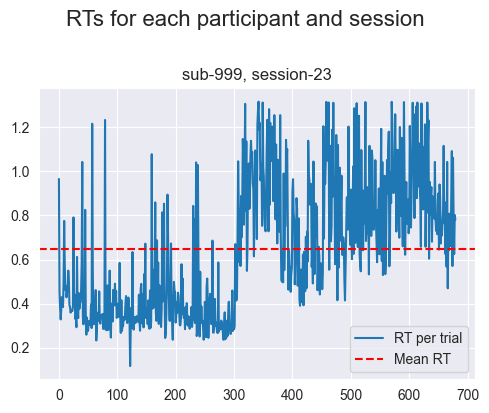

In [9]:
# Subplots for RT
## Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharex=True, sharey=True)
fig.suptitle('RTs for each participant and session', fontsize=16, y=1.02)

if n_rows == 1 or n_cols == 1:
    axes = np.array(axes).reshape(n_rows, n_cols)

## Loop through each combination of 'session' and 'subject_id' and create a plot
for i, session in enumerate(unique_sessions):
    for j, subject_id in enumerate(unique_subject_ids):
        ax_index = j * len(unique_sessions) + i
        ax = axes[j, i]

        ## Filter the dataframe for the current session and subject_id
        subset = combined_results_dataframe[(combined_results_dataframe['session'] == session) & (combined_results_dataframe['subject_id'] == subject_id)]

        ## Plot
        ax.plot(subset['RT_s'].values, label=f'RT per trial')
        ax.axhline(subset['RT_s'].mean(), color='r', linestyle='--', label='Mean RT')
        ax.set_title(f'{subject_id}, {session}')
        ax.legend()

## Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'RT_for_each_participant_and_session.pdf'))
plt.show()

Analyse response time for happy-angry approach-avoid, check manuscript


In [10]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3935/3565846324.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)


# Statistics
Start by checking if the objectively correct answers significantly differ from chance

In [11]:
# Filter out trials with 50% reward probability and without responses
stats_dataframe = combined_results_dataframe.drop(combined_results_dataframe[(combined_results_dataframe.probability_condition == 50) | (combined_results_dataframe.objectively_correct == 'Late')].index, inplace=False)
# Calculate the total number of successes and the total number of trials
total_successes = stats_dataframe['objectively_correct_boolean'].sum()
total_trials = len(stats_dataframe)

# Calculate expected successes and failures if each trial has a 50% chance of success
expected_successes = total_trials * 0.5
expected_failures = total_trials * 0.5

# Perform the chi-square goodness of fit test
chi2_stat, p_value = chisquare([total_successes, total_trials - total_successes],
                               f_exp=[expected_successes, expected_failures])

print(chi2_stat, p_value)

0.037821482602118005 0.8458020427951252


In [12]:
# Multiply the boolean response by 100 to get percentages, can only do this after the stats
combined_results_dataframe['objectively_correct_boolean'] *= 100

# Objectively correct answer binned after every switch

In [13]:
# Create a dataframe with objectively correct responses up to 12 trials after switch
unique_stimuli_types = combined_results_dataframe['stimuli_type'].unique()
row_index = 0

objectively_correct_answers_per_switch_block = pd.DataFrame()

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]
        
        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        
        # Filter out trials with 50% reward probability and without responses
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.drop(combined_results_grouped_dataframe[(combined_results_grouped_dataframe.probability_condition == 50) | (combined_results_grouped_dataframe.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.reset_index()
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()
        print(f'{index_stimuli}, {index_subject_id}, {switches_reward}')
        
        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = dataframe_containing_groups_filtered.iloc[values:values+13]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 8: 6, 9: 7, 10: 8, 11: 9, 12: 10, 13: 11, 14: 12})

3, sub-999, [0, 28, 60, 70, 82, 92, 104, 136, 164, 177, 187, 201, 213, 244, 271, 284, 304, 318]
1, sub-999, [0, 28, 60, 70, 82, 92, 104, 136, 163, 176, 186, 200, 212, 242, 270, 284, 294, 306, 319]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3935/1628670542.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3935/1628670542.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)


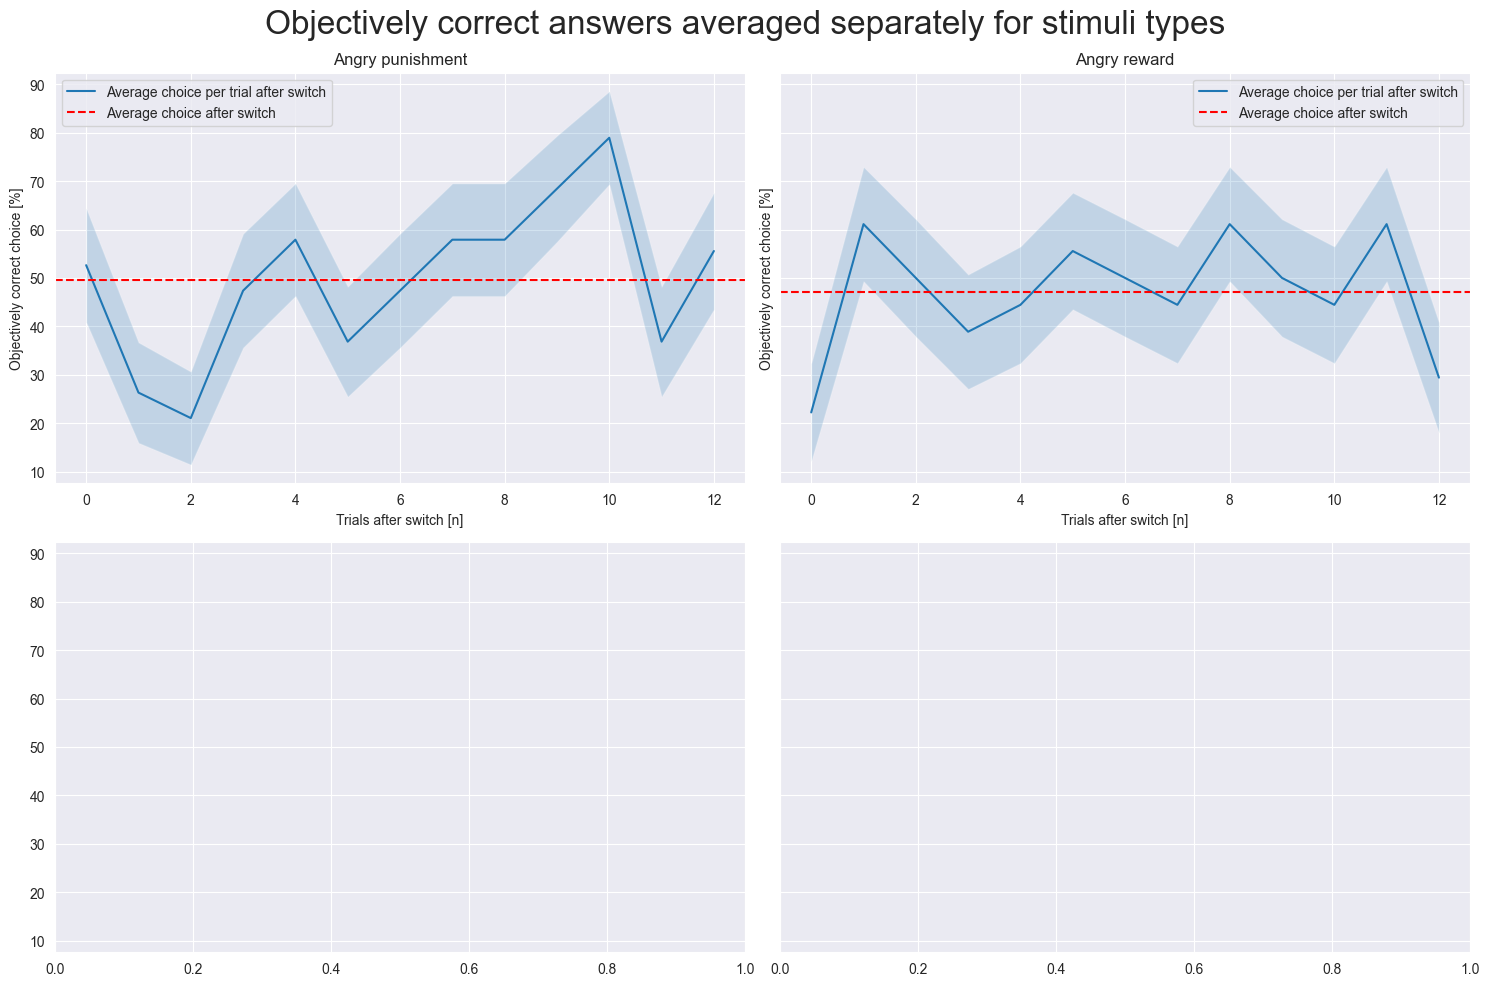

In [14]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged separately for stimuli types', fontsize=24, y=0.982)

stimuli_types_list = ['Angry punishment','Angry reward','Happy punishment','Happy reward']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = np.arange(len(means.columns))
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches-0_12.pdf'))
plt.show()

## objectively correct answers without binning
Now we'll look at the objectively correct answers in a sequential manner, so without binning them based on switches in reward contingencies.
Plot probability of correct response on Y-axis to trials on X-axis

In [15]:
# Take the mean from all 12 trials after each switch
trials_after_switch_to_plot = list(range(0,13))
intermediate_dataframe = objectively_correct_answers_per_switch_block
intermediate_dataframe['switch_number'] = intermediate_dataframe.groupby(['subject_id','stimuli_type']).cumcount()
print(intermediate_dataframe)

# Preparation for loop
unique_switches = intermediate_dataframe['switch_number'].unique()
column_names = ['stimuli_type', 'switch'] + trials_after_switch_to_plot
objectively_correct_answers_averaged_per_switch_block = pd.DataFrame(columns = column_names)

# Loop through each stimulus and switch type
for index_stimuli, value_stimuli in enumerate(unique_stimuli_types):
    for index_switch, value_switch in enumerate(unique_switches):
        filtered_dataframe = intermediate_dataframe[(intermediate_dataframe['stimuli_type'] == value_stimuli) & (intermediate_dataframe['switch_number'] == value_switch)]
        list_with_averages = [value_stimuli, value_switch] + (filtered_dataframe[trials_after_switch_to_plot].mean()).to_list()
        objectively_correct_answers_averaged_per_switch_block.loc[len(objectively_correct_answers_averaged_per_switch_block)] = list_with_averages

objectively_correct_answers_averaged_per_switch_block['mean'] = objectively_correct_answers_averaged_per_switch_block[trials_after_switch_to_plot].mean(axis=1)

   subject_id  stimuli_type    0    1    2    3    4    5    6    7    8    9  \
0     sub-999             3    0    0  100    0    0    0    0    0  100  100   
1     sub-999             3  100  100  100  100    0    0    0    0  100    0   
2     sub-999             3    0  100  100    0  100  100  100  100    0  100   
3     sub-999             3  100  100  100    0  100  100    0    0  100    0   
4     sub-999             3    0    0    0    0    0  100    0    0  100    0   
5     sub-999             3    0  100    0    0  100  100  100  100    0    0   
6     sub-999             3    0    0    0    0    0    0  100    0    0    0   
7     sub-999             3    0  100  100  100    0  100  100    0    0  100   
8     sub-999             3    0  100  100    0    0    0  100    0    0    0   
9     sub-999             3    0  100  100  100  100  100    0  100  100  100   
10    sub-999             3    0    0    0  100    0    0    0  100    0    0   
11    sub-999             3 

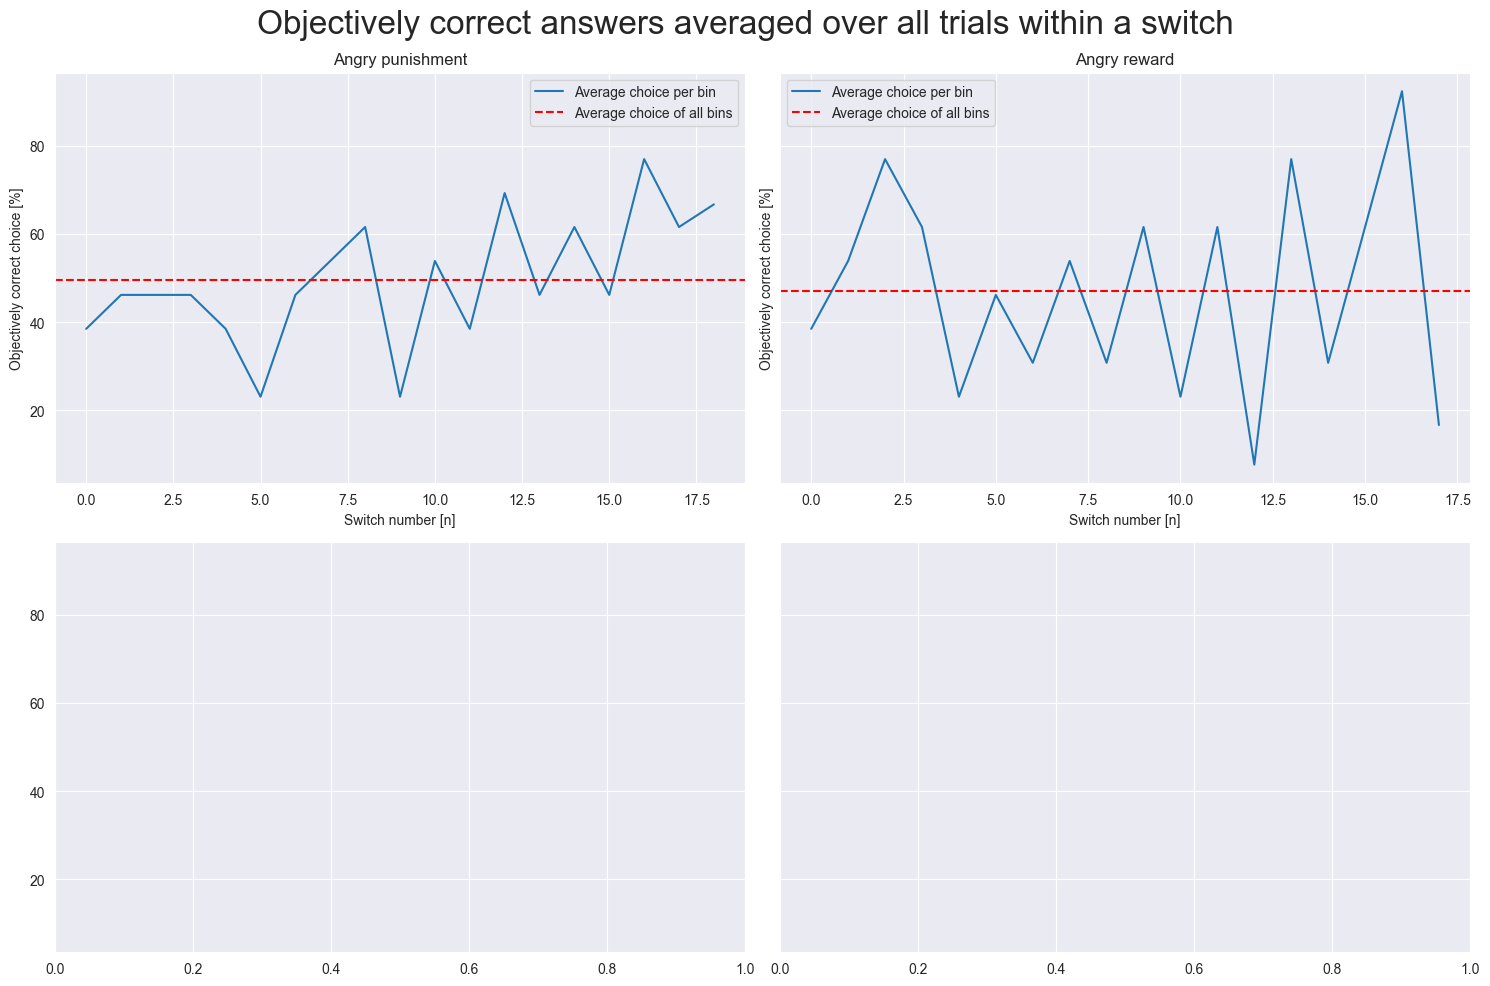

In [16]:
# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged over all trials within a switch', fontsize=24, y=0.982)

for index_stimuli, value_stimuli in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    filtered_dataframe = objectively_correct_answers_averaged_per_switch_block[objectively_correct_answers_averaged_per_switch_block['stimuli_type'] == value_stimuli]

    axs[index_stimuli].plot(unique_switches, filtered_dataframe['mean'], label='Average choice per bin')
    axs[index_stimuli].axhline((average_choice_after_switch_total[index_stimuli]), color='r', linestyle='--', label='Average choice of all bins')
    axs[index_stimuli].set_title(stimuli_types_list[index_stimuli])
    axs[index_stimuli].set_xlabel('Switch number [n]')
    axs[index_stimuli].set_ylabel('Objectively correct choice [%]')
    axs[index_stimuli].legend()
    axs[index_stimuli].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_trials_within_switch.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 12 trials before the switch and ending 4 after.

In [17]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-12, 5))

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values-12:values+5]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns={0: 'subject_id', 1: 'stimuli_type', 2: -12, 3: -11, 4: -10, 5: -9, 6: -8, 7: -7, 8: -6, 9: -5, 10: -4, 11: -3, 12: -2, 13: -1, 14: 0, 15: 1, 16: 2, 17: 3, 18: 4})

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3935/3754995200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3935/3754995200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)


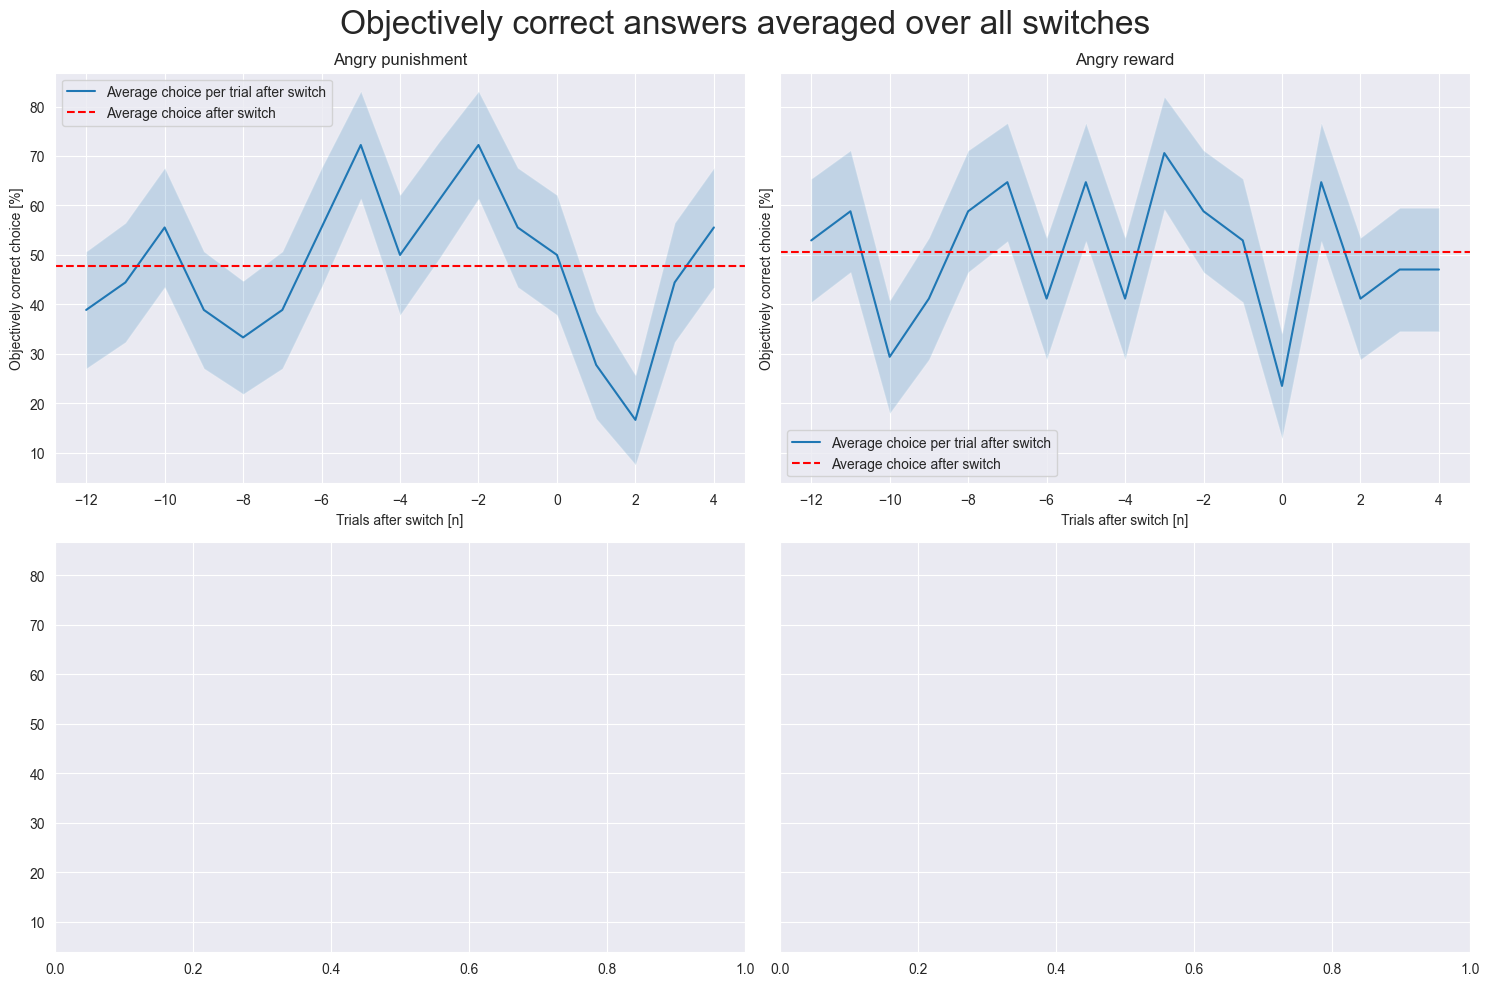

In [18]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged over all switches', fontsize=24, y=0.982)

stimuli_types_list = ['Angry punishment','Angry reward','Happy punishment','Happy reward']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches-12_4.pdf'))
plt.show()

# Objectively correct answers binned around a switch
Starting 4 trials before the switch and ending 12 after.

In [19]:
# Create new plots with different intervals that also contain the 50% trials
objectively_correct_answers_per_switch_block = pd.DataFrame()

plot_range = list(range(-4, 13))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: -4, 3: -3, 4: -2, 5: -1, 6: 0, 7: 1, 8: 2, 9: 3, 10: 4, 11: 5, 12: 6, 13: 7, 14: 8, 15: 9, 16: 10, 17: 11, 18: 12}

for index_stimuli in unique_stimuli_types:
    for index_subject_id in unique_subject_ids:
        combined_results_grouped_dataframe = combined_results_dataframe[(combined_results_dataframe['stimuli_type'] == index_stimuli) & (combined_results_dataframe['subject_id'] == index_subject_id)]

        # Add column that notes if a switch occurred recently
        combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
        # Filter out trials with 50% reward probability
        dataframe_containing_groups_filtered = combined_results_grouped_dataframe.reset_index()
        dataframe_containing_groups_filtered = dataframe_containing_groups_filtered.drop(dataframe_containing_groups_filtered[(dataframe_containing_groups_filtered.probability_condition == 50) | (dataframe_containing_groups_filtered.objectively_correct == 'Late')].index, inplace=False)

        # Add switches to a list
        switches_reward = dataframe_containing_groups_filtered.index[dataframe_containing_groups_filtered['switch'] == True].tolist()

        for index_switches, values in enumerate(switches_reward):
            switches_dataframe = combined_results_grouped_dataframe.iloc[values+min(plot_range):values+max(plot_range)+1]
            objectively_correct_after_switch = [index_subject_id, index_stimuli]
            objectively_correct_after_switch.extend(switches_dataframe['objectively_correct_boolean'].tolist())
            objectively_correct_after_switch = pd.DataFrame([objectively_correct_after_switch])
            objectively_correct_answers_per_switch_block = pd.concat([objectively_correct_answers_per_switch_block, objectively_correct_after_switch])
            row_index = row_index + 1

objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.reset_index(drop = True)
objectively_correct_answers_per_switch_block = objectively_correct_answers_per_switch_block.rename(columns=mapping)
print(objectively_correct_answers_per_switch_block)

   subject_id  stimuli_type   -4   -3   -2   -1    0    1    2    3    4    5  \
0     sub-999             3    0    0    0    0    0    0  100    0    0    0   
1     sub-999             3  100  100  100    0  100  100  100  100    0    0   
2     sub-999             3    0  100  100    0    0  100  100    0  100  100   
3     sub-999             3  100  100    0  100  100  100  100    0  100  100   
4     sub-999             3  100    0  100  100    0    0    0    0    0  100   
5     sub-999             3    0    0  100    0    0  100    0    0  100  100   
6     sub-999             3    0    0    0  100    0    0    0    0    0    0   
7     sub-999             3    0  100  100  100    0  100  100  100    0  100   
8     sub-999             3    0  100  100  100    0  100    0  100    0    0   
9     sub-999             3    0    0  100    0    0  100  100  100  100  100   
10    sub-999             3    0  100  100  100    0    0    0  100    0    0   
11    sub-999             3 

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3935/2712700415.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3935/2712700415.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_grouped_dataframe['switch'] = combined_results_grouped_dataframe['probability_condition'].diff().ne(0)


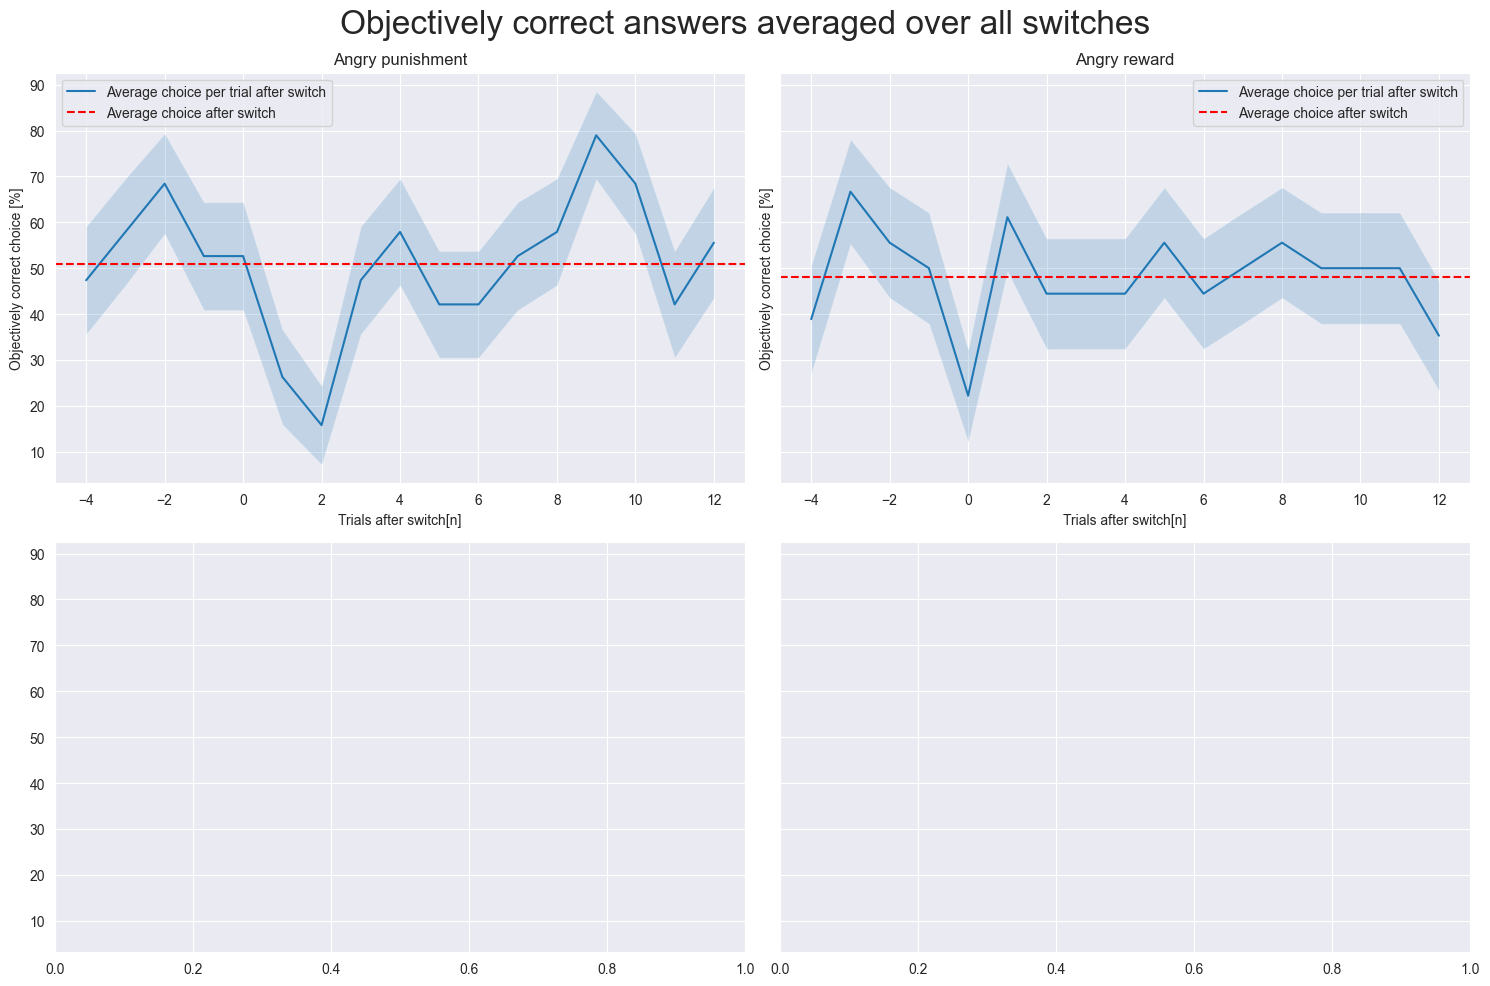

In [20]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = objectively_correct_answers_per_switch_block.set_index('stimuli_type')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('stimuli_type').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('stimuli_type').sem()

# Plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged over all switches', fontsize=24, y=0.982)

stimuli_types_list = ['Angry punishment','Angry reward','Happy punishment','Happy reward']

stimuli_types = means.index
for i, stimuli_type in enumerate(stimuli_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[stimuli_type]
    std_values = stds.loc[stimuli_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(stimuli_types_list[i])
    axs[i].set_xlabel('Trials after switch[n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_over_all_switches-4_12.pdf'))
plt.show()

# Subplots for incongruent and congruent switches

In [21]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 13))
mapping = {0: 'stimuli_type', 1: 'subject_id', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 15: 12}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe(combined_results_dataframe,
                                                                 unique_subject_ids,
                                                                 unique_stimuli_types,
                                                                 'congruency',
                                                                 plot_range,
                                                                 mapping)
print(all_switches_dataframe)

   stimuli_type  subject_id   congruency    0    1    2    3    4    5    6  \
0       sub-999           3    congruent    0    0  100    0    0    0    0   
1       sub-999           3    congruent    0  100  100    0  100  100  100   
2       sub-999           3    congruent    0    0    0    0    0  100    0   
3       sub-999           3    congruent    0    0    0    0    0    0  100   
4       sub-999           3    congruent    0  100  100    0    0    0  100   
5       sub-999           3    congruent    0    0    0  100    0    0    0   
6       sub-999           3    congruent  100    0    0    0    0    0    0   
7       sub-999           3    congruent    0    0    0  100    0    0    0   
8       sub-999           3    congruent    0    0    0    0    0  100    0   
9       sub-999           3  incongruent  100  100  100  100    0    0    0   
10      sub-999           3  incongruent  100  100  100    0  100  100    0   
11      sub-999           3  incongruent    0  100  

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:495: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:495: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['switch'] = dataframe_single_group['probability_condition'].diff().ne(0)


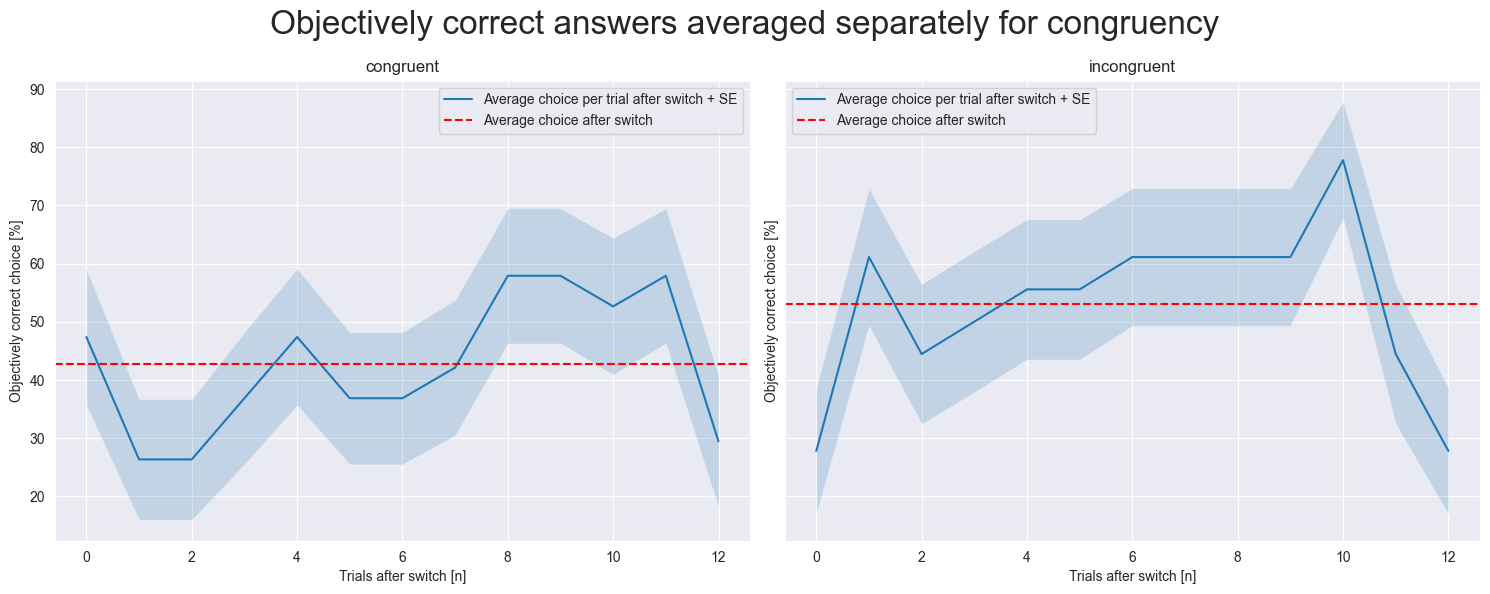

In [22]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('congruency')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged separately for congruency', fontsize=24, y=0.982)

congruency_list = all_switches_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_per_congruency.pdf'))
plt.show()

# Subplots for reversal and non-reversal switches

In [23]:
# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 13))
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'all_reversals', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10, 14: 11, 15: 12}
group_name = 'congruency'
unique_group_types = combined_results_dataframe[group_name].unique()


all_switches_dataframe = utils.analysis_functions.find_switches_in_dataframe_separate_reversals(combined_results_dataframe,
                                                                                          unique_subject_ids,
                                                                                          unique_stimuli_types,
                                                                                          plot_range,
                                                                                          mapping)
print(all_switches_dataframe)

   subject_id  stimuli_type  all_reversals    0    1    2    3    4    5    6  \
0     sub-999             3            1.0    0    0  100    0    0    0    0   
1     sub-999             3            1.0  100  100  100  100    0    0    0   
2     sub-999             3            1.0    0  100  100    0  100  100  100   
3     sub-999             3            1.0  100  100  100    0  100  100    0   
4     sub-999             3            1.0    0    0    0    0    0  100    0   
5     sub-999             3            1.0    0  100    0    0  100  100  100   
6     sub-999             3            1.0    0    0    0    0    0    0  100   
7     sub-999             3            1.0    0  100  100  100    0  100  100   
8     sub-999             3            1.0    0  100  100    0    0    0  100   
9     sub-999             3            1.0    0  100  100  100  100  100    0   
10    sub-999             3            1.0    0    0    0  100    0    0    0   
11    sub-999             3 

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:549: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:549: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_single_group['all_switches'] = dataframe_single_group['probability_condition'].diff().ne(0)


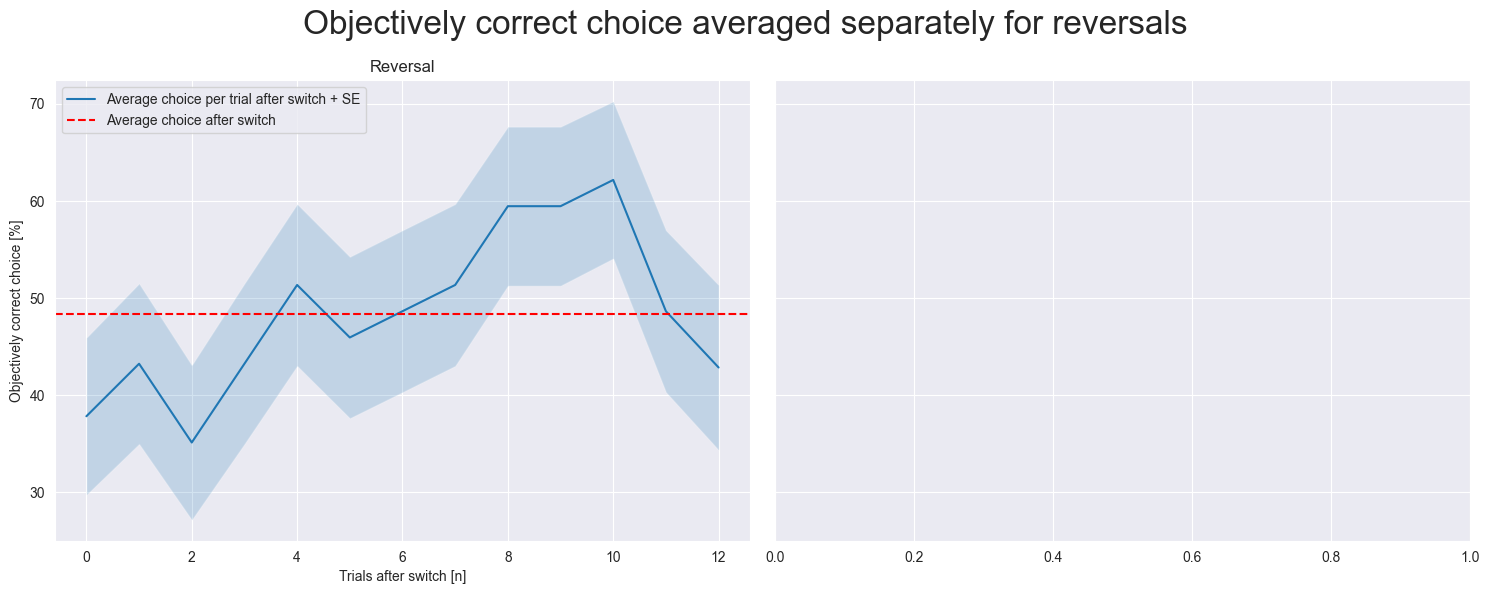

In [24]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_switches_dataframe.set_index('all_reversals')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('all_reversals').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('all_reversals').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False,
                        sharey=True)  # Adjust based on the number of stimuli_types
axs = axs.flatten()  # Flatten to iterate easily

fig.suptitle('Objectively correct choice averaged separately for reversals', fontsize=24, y=0.982)

reversal_list = ['Reversal','Non-reversal']

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--',
                   label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(reversal_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_per_reversal.pdf'))
plt.show()

# Time before stabilisation
This will be the amount of trials before participants reach an average response of x%

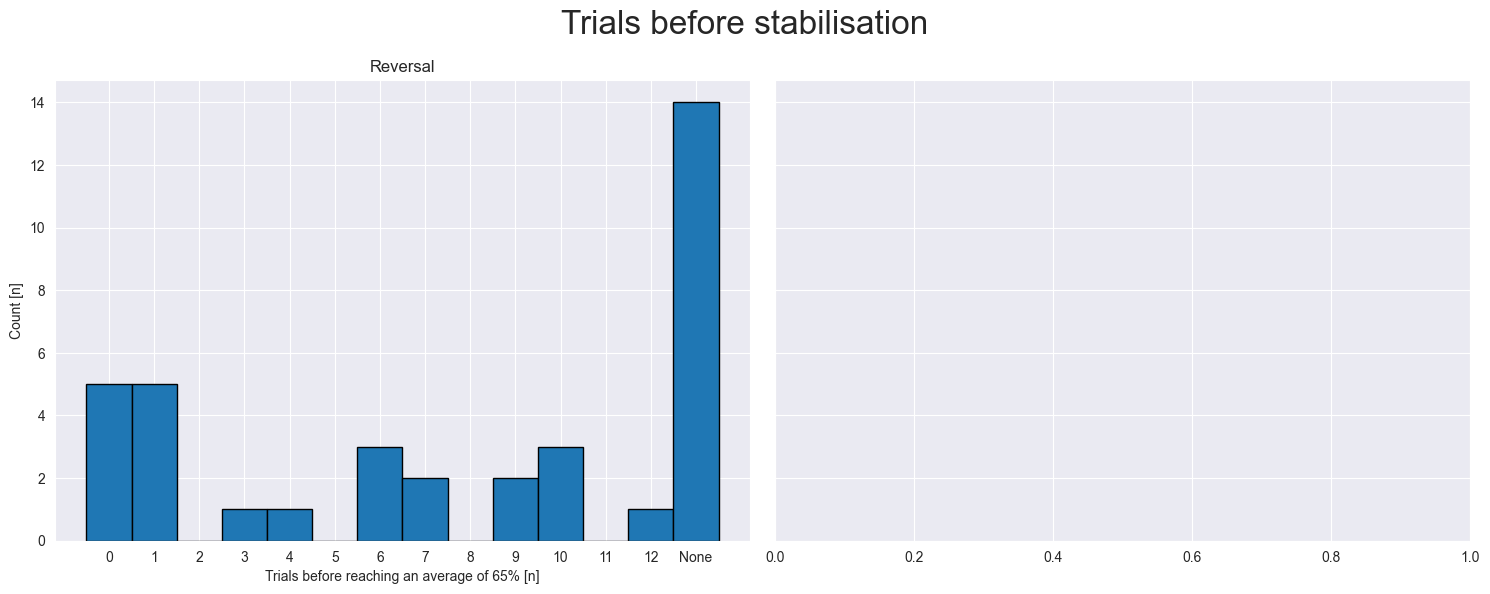

In [25]:
# Set some plotting guidelines
stable_performance = 65
bin_range = [0, 12]
sequence_bin_range = range(min(bin_range), max(bin_range) + 3)
sequence_tick_range = range(min(bin_range), max(bin_range) + 2)

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)

fig.suptitle('Trials before stabilisation', fontsize=24, y=0.982)

# Bin edges centered around the ticks
bin_edges = [i - 0.5 for i in sequence_bin_range]

# Plot for switch value 1.0
reversal_results = utils.analysis_functions.trials_before_stabilisation(combined_results_dataframe, stable_performance, bin_range, 1.0)
axes[0].hist(reversal_results['number_of_trials_before_stabilising'], bins=bin_edges, edgecolor='black')
axes[0].set_title(reversal_list[0])
axes[0].set_xlabel(f'Trials before reaching an average of {stable_performance}% [n]')
axes[0].set_ylabel('Count [n]')
axes[0].set_xticks(sequence_tick_range)

ticks = axes[0].get_xticks()
tick_labels = axes[0].get_xticklabels()

# Replace the label at position 13 with None
tick_labels = [label.get_text() if tick != 13 else 'None' for tick, label in zip(ticks, tick_labels)]

# Set the new tick labels
axes[0].set_xticklabels(tick_labels)
'''
# Plot for switch value 2.0
nonreversal_results = utils.analysis_functions.trials_before_stabilisation(combined_results_dataframe, stable_performance, bin_range, 2.0)
axes[1].hist(nonreversal_results['number_of_trials_before_stabilising'], bins=bin_edges, edgecolor='black')
axes[1].set_title(reversal_list[1])
axes[1].set_xlabel(f'Trials before reaching an average of {stable_performance}% [n]')
axes[1].set_xticks(sequence_tick_range)

ticks = axes[1].get_xticks()
tick_labels = axes[1].get_xticklabels()

# Replace the label at position 13 with None
tick_labels = [label.get_text() if tick != 13 else 'None' for tick, label in zip(ticks, tick_labels)]

# Set the new tick labels
axes[1].set_xticklabels(tick_labels)
'''
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'trials_before_stabilisation.pdf'))
plt.show()

# Chance of a forward response around switch
Here, we plot the chance of a forward response around a switch, hoping to capture a flip in the switch for the four categories:
- happy incongruent > congruent
- angry incongruent > congruent
- happy congruent > incongruent
- angry congruent > incongruent

In [26]:
# First create a new dataframe with the 
bin_range = [-10, 10]
dataframe = utils.analysis_functions.bin_responses_for_congruency(combined_results_dataframe, bin_range) 

print(dataframe)

     trials_around_switch  response_int subject_id     session   congruency  \
0                       0             0    sub-999  session-23    congruent   
1                       1           100    sub-999  session-23    congruent   
2                       2           100    sub-999  session-23    congruent   
3                       3             0    sub-999  session-23    congruent   
4                       4             0    sub-999  session-23    congruent   
5                       5             0    sub-999  session-23    congruent   
6                       6           100    sub-999  session-23    congruent   
7                       7           100    sub-999  session-23    congruent   
8                       8           100    sub-999  session-23    congruent   
9                       9           100    sub-999  session-23    congruent   
10                     10           100    sub-999  session-23    congruent   
11                    -10             0    sub-999  

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:143: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe[new_column] = dataframe[old_column].replace(mapping)


['angry' 'happy'] ['congruent_to_incongruent' 'incongruent_to_congruent']


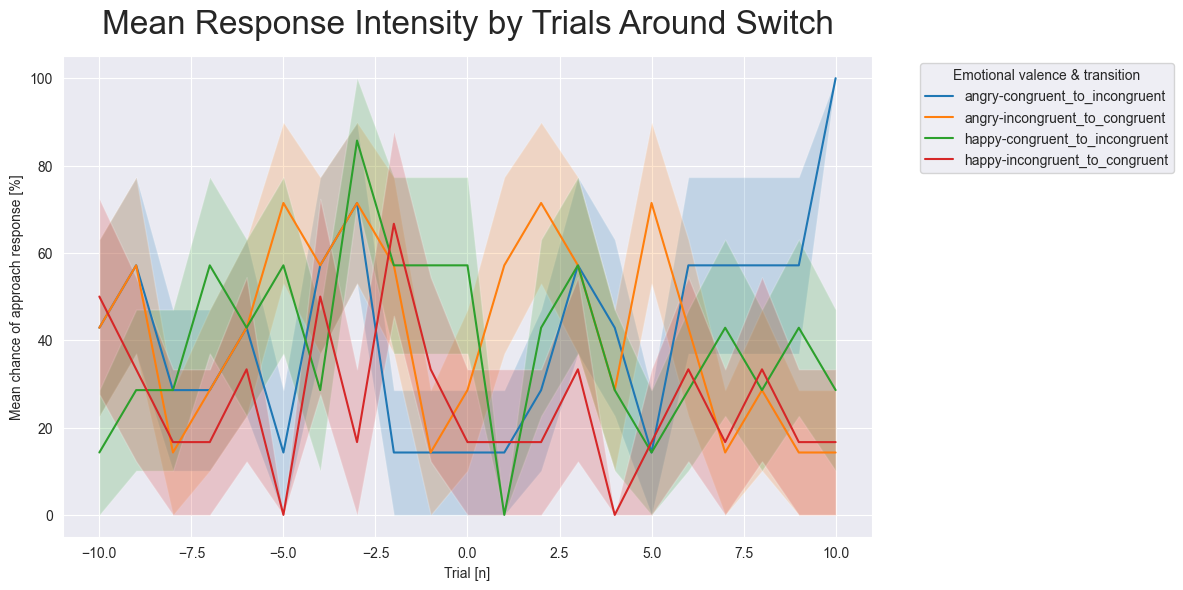

In [27]:
# Group the data
grouped_dataframe = dataframe.groupby(['trials_around_switch', 'emotional_valence', 'transition'])['response_int'].agg(['mean', 'sem']).reset_index()

# Plotting with Matplotlib
plt.figure(figsize=(12, 6))

# Define the unique groups for 'emotional_valence' and 'transition'
emotional_valences = grouped_dataframe['emotional_valence'].unique()
transitions = grouped_dataframe['transition'].unique()
transitions = transitions[transitions != 'no_transition']
print(emotional_valences, transitions)

# Plot each group
for valence in emotional_valences:
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            plt.plot(subset['trials_around_switch'], subset['mean'], label=f'{valence}-{transition}')
            plt.fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

# Customize the plot
plt.xlabel('Trial [n]')
plt.ylabel('Mean chance of approach response [%]')
plt.title('Mean Response Intensity by Trials Around Switch', fontsize=24, y=1.03)
plt.legend(title='Emotional valence & transition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'Average response by emotional valence and transition.pdf'))
# Show the plot
plt.show()

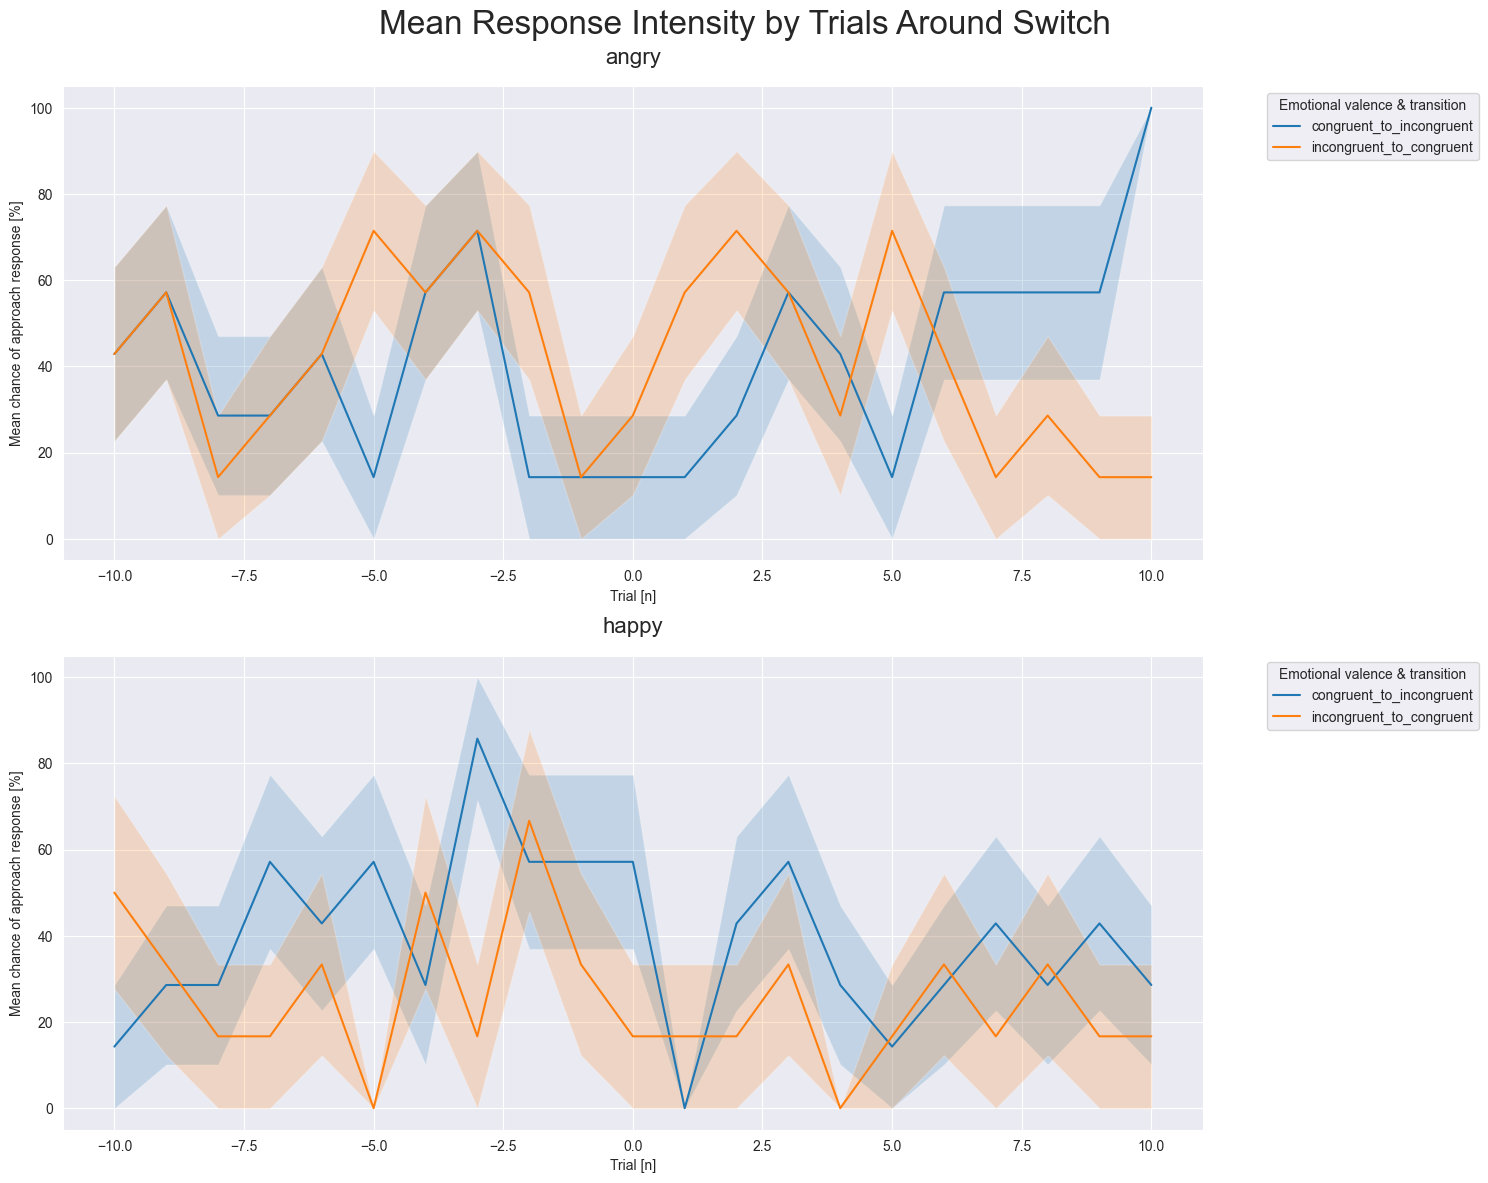

In [28]:
# Plotting with Matplotlib
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), sharey=True)

fig.suptitle('Mean Response Intensity by Trials Around Switch', fontsize=24, y=0.982)

# Plot each group
for valence_index, valence_value in enumerate(emotional_valences):
    for transition in transitions:
        subset = grouped_dataframe[(grouped_dataframe['emotional_valence'] == valence_value) & (grouped_dataframe['transition'] == transition)]
        current_emotion = subset['emotional_valence'].unique()
        current_transition = subset['transition'].unique()
        if not subset.empty:
            axes[valence_index].plot(subset['trials_around_switch'], subset['mean'], label=f'{transition}')
            axes[valence_index].fill_between(subset['trials_around_switch'], subset['mean'] - subset['sem'], subset['mean'] + subset['sem'], alpha=0.2)

    # Customize the plot
    axes[valence_index].set_xlabel('Trial [n]')
    axes[valence_index].set_ylabel('Mean chance of approach response [%]')
    axes[valence_index].set_title(valence_value, fontsize=16, y=1.03)
    axes[valence_index].legend(title='Emotional valence & transition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(output_dir, 'Average response by emotional valence and transition grouped.pdf'))
# Show the plot
plt.show()

# Plot volatile and stable blocks separately

In [33]:
# Check if a block is volatile or stable
dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
dataframe = utils.analysis_functions.check_volatility(dataframe)
filtered_df = dataframe[dataframe['stimuli_type'] == 1]
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Create new plots with different intervals that also contain the 50% trials
plot_range = list(range(0, 11))
mapping = {0: 'stimuli_type', 1: 'subject_id', 2: 'volatility', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6, 10: 7, 11: 8, 12: 9, 13: 10}
group_name = 'volatility'
unique_group_types = dataframe[group_name].unique()


dataframe = utils.analysis_functions.find_switches_in_dataframe(dataframe,
                                                                unique_subject_ids,
                                                                unique_stimuli_types,
                                                                'volatility',
                                                                plot_range,
                                                                mapping)

print(dataframe)

   stimuli_type  subject_id volatility    0    1    2    3    4    5    6  \
0       sub-999           3   volatile    0    0  100    0    0    0    0   
1       sub-999           3   volatile  100  100  100    0  100  100    0   
2       sub-999           3   volatile    0    0    0    0    0  100    0   
3       sub-999           3   volatile    0  100    0    0  100  100  100   
4       sub-999           3   volatile    0    0    0    0    0    0  100   
5       sub-999           3   volatile    0  100  100  100  100  100    0   
6       sub-999           3   volatile    0    0    0  100    0    0    0   
7       sub-999           3   volatile    0  100    0    0  100  100  100   
8       sub-999           3   volatile  100    0    0    0    0    0    0   
9       sub-999           3   volatile    0  100  100  100  100    0  100   
10      sub-999           3   volatile  100  100  100  100  100  100  100   
11      sub-999           3   volatile    0    0    0    0    0  100    0   

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:193: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['temp_volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:194: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['volatility'] = ''
/Users/kenneth.van.der.zee/Documents/phd_1_analysis/utils/analysis_functions.py:495: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

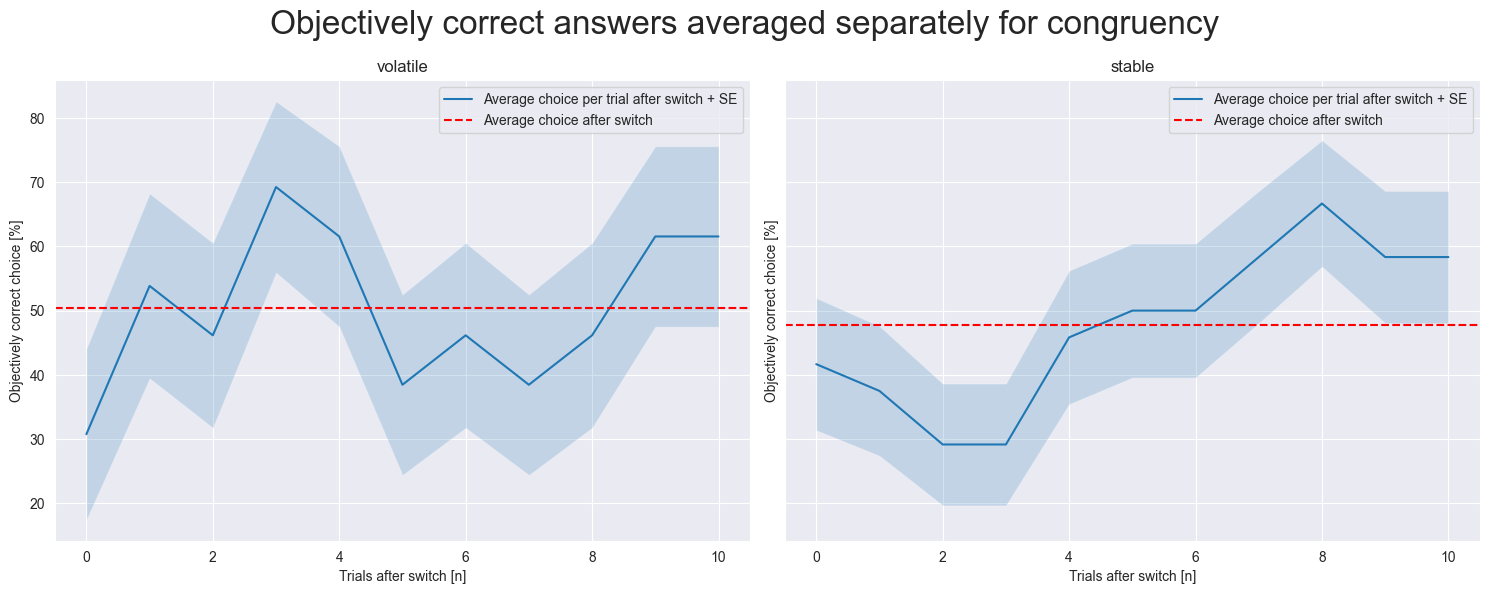

In [34]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = dataframe.set_index('volatility')

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('volatility').mean()
average_choice_after_switch_total = means.mean(axis=1).tolist()
stds = df.groupby('volatility').sem()

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

fig.suptitle('Objectively correct answers averaged separately for congruency', fontsize=24, y=0.982)

congruency_list = dataframe['volatility'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    # Timepoints are the column names converted to integers for x-axis values
    timepoints = plot_range
    mean_values = means.loc[congruency_type]
    std_values = stds.loc[congruency_type]

    axs[i].plot(timepoints, mean_values, label='Average choice per trial after switch + SE')
    axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
    axs[i].axhline((average_choice_after_switch_total[i]), color='r', linestyle='--', label='Average choice after switch')
    #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
    axs[i].set_title(congruency_list[i])
    axs[i].set_xlabel('Trials after switch [n]')
    axs[i].set_ylabel('Objectively correct choice [%]')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'objectively_correct_choices_averaged_per_volatility.pdf'))
plt.show()

In [35]:
# Generate random distribution of integers between 0-10 as the first feature
x1 = np.random.choice([0,1,2,3,4,5,6,7,8,9,10], p=[0.01, 0.01, 0.15, 0.19, 0.05, 0.11, 0.2, 0.16, 0.10, 0.01, 0.01], size=(500))

# Apply random noise on each sample so they don't overlap on the x-axis in scatter plot
idxs = np.arange(len(x1))
out = x1.astype(float)
out.flat[idxs] += np.random.uniform(low=-1, high=1, size=len(idxs))
x1 = out

# Generate random distribution of integers between 6-17 as the second feature
x2 = np.random.choice([6,7,8,9,10,11,12,13,14,15,16,17], p=[0.01, 0.01, 0.15, 0.23, 0.14, 0.06, 0.05, 0.10, 0.12, 0.11, 0.01, 0.01], size=(500))

# Apply random noise on each sample so they don't overlap on the y-axis in scatter plot
idxs = np.arange(len(x2))
out = x2.astype(float)
out.flat[idxs] += np.random.uniform(low=-1, high=1, size=len(idxs))
x2 = out

# Combine features in a list
data_x = [x1, x2]

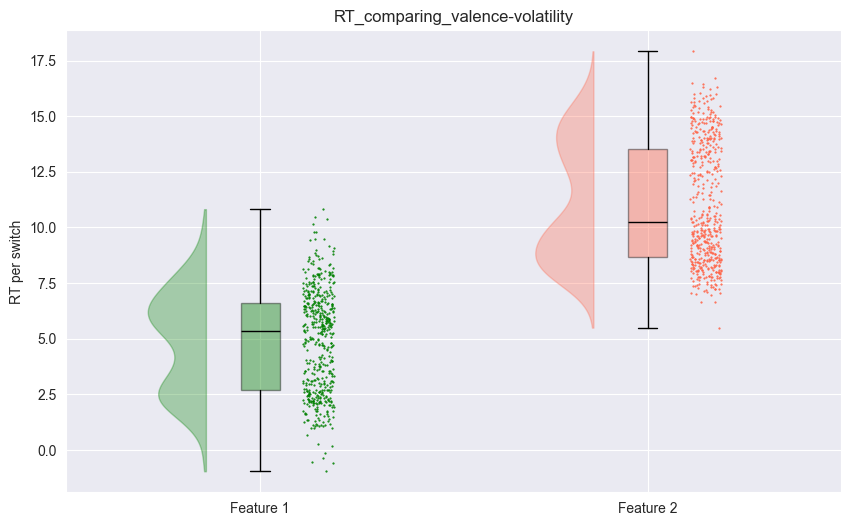

In [37]:
# Create empty plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create a list of colors
plot_colors = ['green', 'tomato']
c = 'black'

# Boxplot data
bp = ax.boxplot(data_x, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(data_x, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(data_x):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Feature 1', 'Feature 2'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence-volatility'

# Save and show plot
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()